# Reddit Virality Prediction: NLP Classification

This notebook builds the NLP part of our group project: predicting whether a Reddit post becomes viral using classical machine-learning models learned in class.

The previous Reddit-V paper evaluated zero-shot LLMs and fine-tuned multimodal models. Here, we use post-title NLP features plus safe metadata with decision tree, random forest, and XGBoost if available.

## 1. Setup

Run this notebook from the project folder in VSCode. If a package is missing, install it in the selected Python environment.

In [1]:
import os
import re
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/reddit_virality_mpl_cache")
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

try:
    import joblib
except ImportError:
    joblib = None
    print("joblib is not installed, so the trained model will not be saved as a .joblib file.")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

try:
    from xgboost import XGBClassifier
except Exception as error:
    XGBClassifier = None
    print("XGBoost unavailable in this environment:", error)

sns.set_theme(style="whitegrid", context="notebook")

XGBoost unavailable in this environment: 
XGBoost Library (libxgboost.dylib) could not be loaded.
Likely causes:
  * OpenMP runtime is not installed
    - vcomp140.dll or libgomp-1.dll for Windows
    - libomp.dylib for Mac OSX
    - libgomp.so for Linux and other UNIX-like OSes
    Mac OSX users: Run `brew install libomp` to install OpenMP runtime.

  * You are running 32-bit Python on a 64-bit OS

Error message(s): ["dlopen(/private/tmp/reddit_nlp_venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib, 0x0006): Library not loaded: @rpath/libomp.dylib\n  Referenced from: <4E82201A-ED82-3451-AD25-7886C77941A1> /private/tmp/reddit_nlp_venv/lib/python3.12/site-packages/xgboost/lib/libxgboost.dylib\n  Reason: tried: '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/opt/homebrew/opt/libomp/lib/libomp.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/opt/homebrew/op

In [2]:
def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data" / "reddit_virality_train.csv").exists():
            return candidate
    raise FileNotFoundError("Could not find data/reddit_virality_train.csv. Open VSCode at the project folder.")


ROOT = find_project_root()
DATA_PATH = ROOT / "data" / "reddit_virality_train.csv"
FIG_DIR = ROOT / "figures" / "reddit_virality_nlp"
TABLE_DIR = ROOT / "tables" / "reddit_virality_nlp"
MODEL_DIR = ROOT / "models"

for directory in [FIG_DIR, TABLE_DIR, MODEL_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TARGET = "viral"

DATA_PATH

PosixPath('/Users/nguyenvietcuong/Library/CloudStorage/OneDrive-Personal/Documents/Waseda 2024-2028/5th Semester/Introductory Python/data/reddit_virality_train.csv')

## 2. Load the Dataset

The target column is `viral`, where `1` means viral and `0` means non-viral.

In [3]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(27587, 30)


,Post ID,Subreddit,Post Title,Upvotes,Downvotes,Score,Upvote Ratio,Author,Post Time,Number of Comments,...,First Hour Upvotes,viral,title_length,title_sentiment,hour,day,weekday,month,year,category_encoded
0,1h7hvjd,memes,It’s a full time job,1,0,1,1.00,onegonethusband,2024-12-05 19:44:21,0,...,1.0,0,20,0.35,19,5,3,12,2024,3
1,1h7hqx1,memes,Maybe we do need the Bible in schools lol,4,0,4,1.00,DrizzleDrain,2024-12-05 19:38:53,1,...,4.0,0,41,0.80,19,5,3,12,2024,3
2,1h7hpdm,memes,Sad Guts,0,0,0,0.50,urzaga,2024-12-05 19:37:07,0,...,0.0,0,8,-0.50,19,5,3,12,2024,3
3,1h7hksk,memes,Sad Hulk,6,0,6,0.88,Clear-Example3029,2024-12-05 19:31:51,1,...,6.0,0,8,-0.50,19,5,3,12,2024,3
4,1h7hiw6,memes,"Hey, neck-bearded fedora-wearers. These memes ...",2,0,2,0.63,AverageSign,2024-12-05 19:29:40,1,...,2.0,0,93,0.00,19,5,3,12,2024,3


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27587 entries, 0 to 27586
Data columns (total 30 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Post ID                27587 non-null  str    
 1   Subreddit              27587 non-null  str    
 2   Post Title             27587 non-null  str    
 3   Upvotes                27587 non-null  int64  
 4   Downvotes              27587 non-null  int64  
 5   Score                  27587 non-null  int64  
 6   Upvote Ratio           27587 non-null  float64
 7   Author                 27587 non-null  str    
 8   Post Time              27587 non-null  str    
 9   Number of Comments     27587 non-null  int64  
 10  Crossposts Count       27587 non-null  int64  
 11  Permalink              27587 non-null  str    
 12  Image URL              27587 non-null  str    
 13  Image Format           27587 non-null  str    
 14  Image Dimensions       27587 non-null  str    
 15  File Size    

## 3. Class Balance

The dataset is imbalanced: viral posts are much less common than non-viral posts. This is why F1, balanced accuracy, recall, and ROC AUC are more informative than accuracy alone.

,posts
viral,
Non-viral,24090
Viral,3497


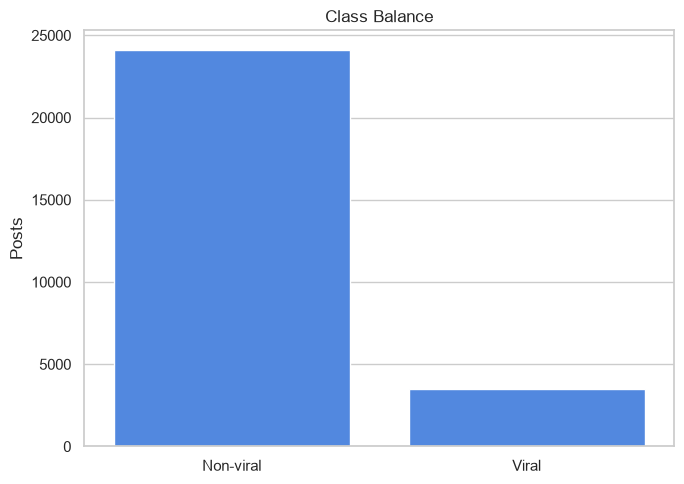

In [5]:
df[TARGET] = df[TARGET].astype(int)
class_counts = df[TARGET].value_counts().rename(index={0: "Non-viral", 1: "Viral"})
display(class_counts.to_frame("posts"))

plt.figure(figsize=(7, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, color="#3B82F6")
plt.title("Class Balance")
plt.xlabel("")
plt.ylabel("Posts")
plt.tight_layout()
plt.show()

## 4. NLP Feature Engineering

The main NLP feature is the Reddit post title. We use TF-IDF on the title text and add simple title-level features such as word count, punctuation, and uppercase ratio.

In [6]:
def clean_title(text):
    text = "" if pd.isna(text) else str(text)
    text = text.replace("\n", " ").replace("\r", " ")
    text = re.sub(r"https?://\S+|www\.\S+", " urltoken ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip().lower()


def add_title_features(data):
    prepared = data.copy()
    raw_title = prepared["Post Title"].fillna("").astype(str)
    prepared["clean_title"] = raw_title.map(clean_title)
    prepared["title_word_count"] = raw_title.str.split().map(len)
    prepared["title_char_count"] = raw_title.str.len()
    prepared["title_avg_word_len"] = raw_title.map(
        lambda value: np.mean([len(word) for word in value.split()]) if value.split() else 0
    )
    prepared["title_question_marks"] = raw_title.str.count(r"\?")
    prepared["title_exclamation_marks"] = raw_title.str.count("!")
    prepared["title_has_number"] = raw_title.str.contains(r"\d", regex=True).astype(int)
    prepared["title_uppercase_ratio"] = raw_title.map(
        lambda value: sum(char.isupper() for char in value) / max(len(value), 1)
    )
    return prepared


df = add_title_features(df)
df[["Post Title", "clean_title", "title_word_count", "title_uppercase_ratio"]].head()

,Post Title,clean_title,title_word_count,title_uppercase_ratio
0,It’s a full time job,it’s a full time job,5,0.050000
1,Maybe we do need the Bible in schools lol,maybe we do need the bible in schools lol,9,0.048780
2,Sad Guts,sad guts,2,0.250000
3,Sad Hulk,sad hulk,2,0.250000
4,"Hey, neck-bearded fedora-wearers. These memes ...","hey, neck-bearded fedora-wearers. these memes ...",13,0.021505


## 5. Choose Model Inputs

We exclude final engagement columns such as `Upvotes`, `Score`, `Upvote Ratio`, and `Number of Comments`. Those columns are outcomes after the post was published, so using them would leak the answer.

In [7]:
safe_metadata_features = [
    "Crossposts Count",
    "Subreddit Subscribers",
    "First Hour Upvotes",
    "title_length",
    "title_sentiment",
    "hour",
    "day",
    "weekday",
    "month",
    "year",
    "File Size",
    "title_word_count",
    "title_char_count",
    "title_avg_word_len",
    "title_question_marks",
    "title_exclamation_marks",
    "title_has_number",
    "title_uppercase_ratio",
]
categorical_features = ["Subreddit", "Category", "Image Format"]

available_numeric = [col for col in safe_metadata_features if col in df.columns]
available_categorical = [col for col in categorical_features if col in df.columns]
model_features = ["clean_title"] + available_numeric + available_categorical

X = df[model_features]
y = df[TARGET]

print("Numeric features:", available_numeric)
print("Categorical features:", available_categorical)
print("Feature table shape:", X.shape)

Numeric features: ['Crossposts Count', 'Subreddit Subscribers', 'First Hour Upvotes', 'title_length', 'title_sentiment', 'hour', 'day', 'weekday', 'month', 'year', 'File Size', 'title_word_count', 'title_char_count', 'title_avg_word_len', 'title_question_marks', 'title_exclamation_marks', 'title_has_number', 'title_uppercase_ratio']
Categorical features: ['Subreddit', 'Category', 'Image Format']
Feature table shape: (27587, 22)


## 6. Train/Test Split and Preprocessing Pipeline

The split is stratified so that the viral/non-viral class balance is preserved in both train and test data.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

preprocess = ColumnTransformer(
    [
        (
            "title_tfidf",
            TfidfVectorizer(
                stop_words="english",
                ngram_range=(1, 2),
                min_df=2,
                max_features=6000,
                sublinear_tf=True,
            ),
            "clean_title",
        ),
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            available_numeric,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=5)),
            ]),
            available_categorical,
        ),
    ],
    sparse_threshold=0.3,
)

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))

Train rows: 22069
Test rows: 5518


## 7. Train Classical ML Models

We compare decision tree, random forest, and XGBoost if the environment can load it.

In [9]:
negative_count = int((y_train == 0).sum())
positive_count = int((y_train == 1).sum())
scale_pos_weight = negative_count / max(positive_count, 1)

models = {
    "Decision Tree": DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=250,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
}

if XGBClassifier is not None:
    models["XGBoost"] = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

models

{'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                        min_samples_leaf=20, random_state=42),
 'Random Forest': RandomForestClassifier(class_weight='balanced_subsample', min_samples_leaf=4,
                        n_estimators=250, n_jobs=-1, random_state=42)}

In [10]:
def safe_roc_auc(y_true, y_score):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, y_score)


def prediction_scores(model, X_part):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_part)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_part)
    return model.predict(X_part)


rows = []
confusion_rows = []
fitted_models = {}

for model_name, estimator in models.items():
    pipeline = Pipeline([
        ("preprocess", preprocess),
        ("model", estimator),
    ])
    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline

    for split_name, X_part, y_part in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        predicted = pipeline.predict(X_part)
        scores = prediction_scores(pipeline, X_part)
        matrix = confusion_matrix(y_part, predicted, labels=[0, 1])
        rows.append({
            "Model": model_name,
            "Dataset": split_name,
            "Accuracy": accuracy_score(y_part, predicted),
            "Balanced Accuracy": balanced_accuracy_score(y_part, predicted),
            "Precision": precision_score(y_part, predicted, zero_division=0),
            "Recall": recall_score(y_part, predicted, zero_division=0),
            "F1": f1_score(y_part, predicted, zero_division=0),
            "ROC AUC": safe_roc_auc(y_part, scores),
        })
        confusion_rows.append({
            "Model": model_name,
            "Dataset": split_name,
            "True Non-viral": int(matrix[0, 0]),
            "False Viral": int(matrix[0, 1]),
            "False Non-viral": int(matrix[1, 0]),
            "True Viral": int(matrix[1, 1]),
        })

performance = pd.DataFrame(rows).round(4)
confusions = pd.DataFrame(confusion_rows)
performance

,Model,Dataset,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC
0,Decision Tree,Train,0.7558,0.8015,0.3254,0.8628,0.4725,0.8891
1,Decision Tree,Test,0.7383,0.7676,0.3011,0.8069,0.4386,0.8478
2,Random Forest,Train,0.7807,0.8001,0.3468,0.8259,0.4885,0.8901
3,Random Forest,Test,0.7717,0.7788,0.3313,0.7883,0.4666,0.8661


## 8. Compare Results

The paper's best zero-shot LLM F1 was 0.399. The dashed line below marks that reference point.

In [11]:
test_performance = performance[performance["Dataset"] == "Test"].sort_values(
    ["F1", "Balanced Accuracy"], ascending=False
)

best_model_name = test_performance.iloc[0]["Model"]
best_pipeline = fitted_models[best_model_name]

display(test_performance)
print("Best model:", best_model_name)
print("Best test F1:", test_performance.iloc[0]["F1"])

,Model,Dataset,Accuracy,Balanced Accuracy,Precision,Recall,F1,ROC AUC
3,Random Forest,Test,0.7717,0.7788,0.3313,0.7883,0.4666,0.8661
1,Decision Tree,Test,0.7383,0.7676,0.3011,0.8069,0.4386,0.8478


Best model: Random Forest
Best test F1: 0.4666


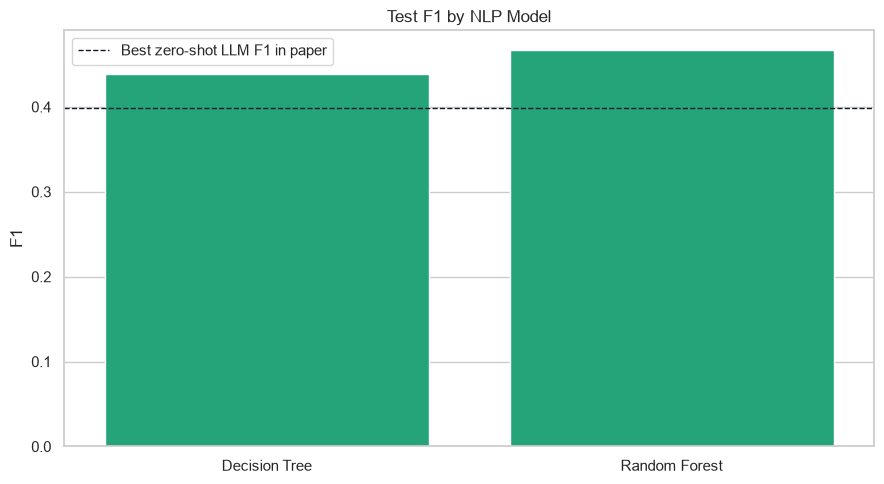

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=performance[performance["Dataset"] == "Test"], x="Model", y="F1", color="#10B981")
plt.axhline(0.399, color="#111827", linestyle="--", linewidth=1, label="Best zero-shot LLM F1 in paper")
plt.title("Test F1 by NLP Model")
plt.xlabel("")
plt.ylabel("F1")
plt.legend()
plt.tight_layout()
plt.show()

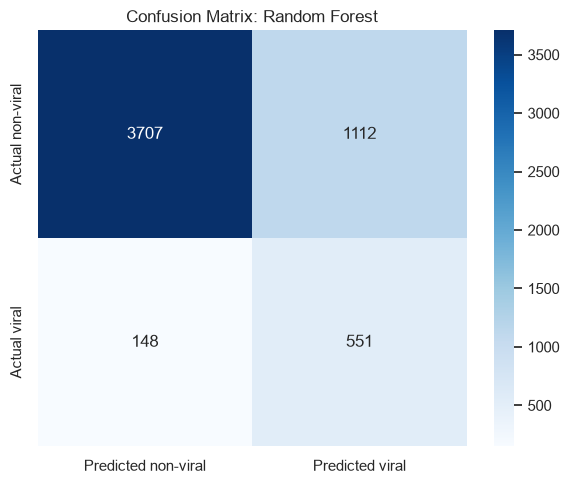

In [13]:
best_predicted = best_pipeline.predict(X_test)
best_matrix = confusion_matrix(y_test, best_predicted, labels=[0, 1])

plt.figure(figsize=(6, 5))
sns.heatmap(
    best_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted non-viral", "Predicted viral"],
    yticklabels=["Actual non-viral", "Actual viral"],
)
plt.title(f"Confusion Matrix: {best_model_name}")
plt.tight_layout()
plt.show()

## 9. Save Outputs

These files can be reused in the report or slides.

## 10. Topic Modeling on Post Titles


- Fit topics using only viral post titles to inspect common viral themes.
- Fit topics using all titles, then compare how common each topic is among viral vs non-viral posts.


In [14]:
performance.to_csv(TABLE_DIR / "nlp_model_performance.csv", index=False)
confusions.to_csv(TABLE_DIR / "confusion_matrices.csv", index=False)
class_counts.to_csv(TABLE_DIR / "class_balance.csv", header=["posts"])
if joblib is not None:
    joblib.dump(best_pipeline, MODEL_DIR / "reddit_virality_nlp_best_model.joblib")
else:
    print("Skipping model save because joblib is not installed.")

summary = pd.DataFrame([
    {
        "rows": len(df),
        "viral_posts": int((df[TARGET] == 1).sum()),
        "nonviral_posts": int((df[TARGET] == 0).sum()),
        "train_rows": len(X_train),
        "test_rows": len(X_test),
        "positive_train_weight": round(scale_pos_weight, 4),
        "best_model": best_model_name,
        "best_test_f1": float(test_performance.iloc[0]["F1"]),
        "best_test_balanced_accuracy": float(test_performance.iloc[0]["Balanced Accuracy"]),
    }
])
summary.to_csv(TABLE_DIR / "nlp_training_summary.csv", index=False)
summary

,rows,viral_posts,nonviral_posts,train_rows,test_rows,positive_train_weight,best_model,best_test_f1,best_test_balanced_accuracy
0,27587,3497,24090,22069,5518,6.8874,Random Forest,0.4666,0.7788


In [15]:
from sklearn.decomposition import NMF

N_TOPICS = 8
N_WORDS = 12


def topic_words(model, feature_names, n_words=N_WORDS):
    rows = []
    labels = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_words:][::-1]
        words = [feature_names[i] for i in top_indices]
        weights = [topic[i] for i in top_indices]
        label = ", ".join(words[:5])
        labels.append(label)
        rows.append({
            "topic_id": topic_idx,
            "topic_label": label,
            "top_words": ", ".join(words),
            "top_word_weights": ", ".join(f"{weight:.4f}" for weight in weights),
        })
    return pd.DataFrame(rows), labels


def fit_nmf_topics(titles, n_topics=N_TOPICS):
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.85,
        max_features=5000,
        sublinear_tf=True,
    )
    matrix = vectorizer.fit_transform(titles)
    model = NMF(
        n_components=n_topics,
        init="nndsvda",
        random_state=RANDOM_STATE,
        max_iter=500,
    )
    topic_matrix = model.fit_transform(matrix)
    feature_names = vectorizer.get_feature_names_out()
    return model, vectorizer, topic_matrix, feature_names


### 10.1 Viral-Only Topics

This model looks only at viral posts, so the topics show repeated themes within viral titles.


In [16]:
viral_df = df[df[TARGET] == 1].copy()
viral_model, viral_vectorizer, viral_topic_matrix, viral_feature_names = fit_nmf_topics(
    viral_df["clean_title"]
)
viral_topic_words, viral_topic_labels = topic_words(viral_model, viral_feature_names)
viral_topic_words


,topic_id,topic_label,top_words,top_word_weights
0,0,"hate, thanks, thanks hate, man, ai","hate, thanks, thanks hate, man, ai, hate ai, i...","1.8871, 1.8276, 1.7826, 0.0551, 0.0431, 0.0421..."
1,1,"like, look, look like, real, cat","like, look, look like, real, cat, looks, reall...","2.4153, 0.1388, 0.1309, 0.1146, 0.1060, 0.0939..."
2,2,"rule, stuck, win, ai, apple","rule, stuck, win, ai, apple, worth, imagine, h...","2.3378, 0.0617, 0.0427, 0.0426, 0.0422, 0.0421..."
3,3,"just, people, just like, guess, meme","just, people, just like, guess, meme, ll, sad,...","2.1474, 0.1395, 0.1290, 0.1062, 0.1011, 0.0893..."
4,4,"oc, 2024, vs, election, world","oc, 2024, vs, election, world, 2023, years, pr...","2.0413, 0.3658, 0.2806, 0.1649, 0.1634, 0.1435..."
5,5,"don, know, don know, think, really","don, know, don know, think, really, say, peopl...","1.6646, 0.8570, 0.5503, 0.2271, 0.1848, 0.1740..."
6,6,"time, kid, good, come, didn","time, kid, good, come, didn, really, seriously...","1.9306, 0.1146, 0.1038, 0.1033, 0.1027, 0.0916..."
7,7,"wild, belongs, work, seen, mean","wild, belongs, work, seen, mean, does, worst, ...","1.9794, 0.1129, 0.1015, 0.0977, 0.0723, 0.0669..."


In [17]:
viral_df["dominant_viral_topic"] = viral_topic_matrix.argmax(axis=1)
viral_df["dominant_viral_topic_label"] = viral_df["dominant_viral_topic"].map(
    dict(enumerate(viral_topic_labels))
)

viral_examples = (
    viral_df[["Post Title", "Subreddit", "Category", "dominant_viral_topic", "dominant_viral_topic_label"]]
    .groupby("dominant_viral_topic", group_keys=False)
    .head(5)
)
viral_examples.head(20)


,Post Title,Subreddit,Category,dominant_viral_topic,dominant_viral_topic_label
90,Meme banning is overused meme,memes,Humor,3,"just, people, just like, guess, meme"
96,Do They ?,memes,Humor,0,"hate, thanks, thanks hate, man, ai"
109,Fear will keep them in line,memes,Humor,6,"time, kid, good, come, didn"
138,Good guys finish last 😕,memes,Humor,5,"don, know, don know, think, really"
143,Why no like Hulk memes?,memes,Humor,1,"like, look, look like, real, cat"
152,Suddenly they don't like open source anymore,memes,Humor,5,"don, know, don know, think, really"
250,I would never violate the rules,memes,Humor,5,"don, know, don know, think, really"
298,Doom Disagrees,memes,Humor,3,"just, people, just like, guess, meme"
318,Nobody cares about what music you listened to ...,memes,Humor,6,"time, kid, good, come, didn"
336,Loophole time,memes,Humor,6,"time, kid, good, come, didn"


### 10.2 Which Topics Are More Common in Viral Posts?

Now we fit topics on all titles, assign each post to its strongest topic, and compare topic prevalence between viral and non-viral posts. A positive `viral_lift` means the topic appears more often among viral posts.


In [18]:
all_model, all_vectorizer, all_topic_matrix, all_feature_names = fit_nmf_topics(df["clean_title"])
all_topic_words, all_topic_labels = topic_words(all_model, all_feature_names)
all_topic_words


,topic_id,topic_label,top_words,top_word_weights
0,0,"hate, thanks, thanks hate, man, ad","hate, thanks, thanks hate, man, ad, meat, face...","2.5613, 2.5297, 2.4738, 0.0515, 0.0335, 0.0324..."
1,1,"rule, fuck, literally, piss, martial","rule, fuck, literally, piss, martial, korea, g...","4.2496, 0.0176, 0.0159, 0.0150, 0.0137, 0.0121..."
2,2,"2024, digital, digital 2024, acrylic, art","2024, digital, digital 2024, acrylic, art, acr...","2.5379, 1.9188, 1.6631, 0.3117, 0.2645, 0.2184..."
3,3,"psbattle, cat, psbattle cat, dog, psbattle dog","psbattle, cat, psbattle cat, dog, psbattle dog...","3.2065, 0.9996, 0.4823, 0.3942, 0.2405, 0.1689..."
4,4,"meme, making, line, making meme, meme line","meme, making, line, making meme, meme line, me...","1.4946, 1.1482, 1.1252, 1.1005, 1.0900, 1.0825..."
5,5,"like, know, look, looks, looks like","like, know, look, looks, looks like, don, look...","3.5587, 0.2685, 0.2538, 0.2392, 0.2194, 0.2020..."
6,6,"invest, template, meme, new, cat","invest, template, meme, new, cat, memes, don, ...","3.1911, 0.1582, 0.1062, 0.1061, 0.1024, 0.0892..."
7,7,"just, time, new, don, know","just, time, new, don, know, day, good, got, gu...","2.9095, 0.1953, 0.1298, 0.1236, 0.1099, 0.1033..."


In [19]:
topic_assignments = df[["Post Title", TARGET, "Subreddit", "Category"]].copy()
topic_assignments["dominant_topic"] = all_topic_matrix.argmax(axis=1)
topic_assignments["topic_label"] = topic_assignments["dominant_topic"].map(
    dict(enumerate(all_topic_labels))
)
topic_assignments["topic_strength"] = all_topic_matrix.max(axis=1)

prevalence = (
    topic_assignments.groupby(["dominant_topic", "topic_label", TARGET])
    .size()
    .reset_index(name="posts")
)
prevalence["class_total"] = prevalence.groupby(TARGET)["posts"].transform("sum")
prevalence["share_within_class"] = prevalence["posts"] / prevalence["class_total"]

prevalence_pivot = prevalence.pivot_table(
    index=["dominant_topic", "topic_label"],
    columns=TARGET,
    values="share_within_class",
    fill_value=0,
).reset_index()
prevalence_pivot = prevalence_pivot.rename(columns={0: "nonviral_share", 1: "viral_share"})
prevalence_pivot["viral_lift"] = prevalence_pivot["viral_share"] - prevalence_pivot["nonviral_share"]
prevalence_pivot = prevalence_pivot.sort_values("viral_lift", ascending=False)
prevalence_pivot


viral,dominant_topic,topic_label,nonviral_share,viral_share,viral_lift
0,0,"hate, thanks, thanks hate, man, ad",0.138190,0.205319,0.067129
7,7,"just, time, new, don, know",0.345164,0.382900,0.037736
5,5,"like, know, look, looks, looks like",0.209298,0.219331,0.010032
1,1,"rule, fuck, literally, piss, martial",0.022208,0.015728,-0.006481
4,4,"meme, making, line, making meme, meme line",0.024408,0.016872,-0.007537
6,6,"invest, template, meme, new, cat",0.040058,0.030312,-0.009746
3,3,"psbattle, cat, psbattle cat, dog, psbattle dog",0.093939,0.070060,-0.023879
2,2,"2024, digital, digital 2024, acrylic, art",0.126733,0.059480,-0.067254


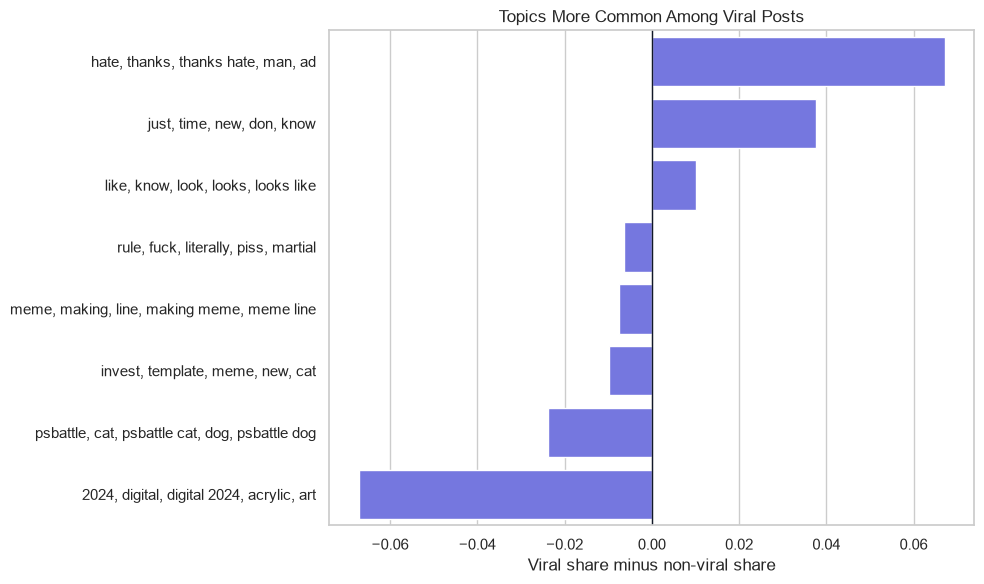

In [20]:
plt.figure(figsize=(10, 6))
plot_data = prevalence_pivot.head(8).copy()
plot_data["short_label"] = plot_data["topic_label"].str.slice(0, 55)
sns.barplot(data=plot_data, y="short_label", x="viral_lift", color="#6366F1")
plt.axvline(0, color="#111827", linewidth=1)
plt.title("Topics More Common Among Viral Posts")
plt.xlabel("Viral share minus non-viral share")
plt.ylabel("")
plt.tight_layout()
plt.show()


In [21]:
viral_topic_words.to_csv(TABLE_DIR / "viral_title_topic_words.csv", index=False)
viral_examples.to_csv(TABLE_DIR / "viral_title_topic_examples.csv", index=False)
all_topic_words.to_csv(TABLE_DIR / "all_title_topic_words.csv", index=False)
topic_assignments.to_csv(TABLE_DIR / "title_topic_assignments.csv", index=False)
prevalence_pivot.to_csv(TABLE_DIR / "topic_prevalence_by_virality.csv", index=False)

print("Saved topic-modeling tables to:", TABLE_DIR)


Saved topic-modeling tables to: /Users/nguyenvietcuong/Library/CloudStorage/OneDrive-Personal/Documents/Waseda 2024-2028/5th Semester/Introductory Python/tables/reddit_virality_nlp


## 11. Interpretation

In the verified script run, random forest achieved test F1 around 0.4666, which is better than the paper's best zero-shot LLM F1 of 0.399 and close to the paper's fine-tuned CLIP score of 0.475.

This suggests that classical ML models with carefully chosen NLP and metadata features can be competitive with heavier black-box approaches for this dataset.